# vel_total — High-Speed Running Distance Prediction

## Overview

**Target:** `vel_total` — daily high-speed running distance in metres (velocity bands 6+7).

| Item | Detail |
|---|---|
| **Zero-inflation** | ~30% of rows are zero (recovery / rest days, position effect) |
| **Loss** | `reg:squarederror` on raw target (Raw MSE) |
| **Feature selection** | SHAP 90% cumulative threshold — two-round tuning (full → reduced) |
| **Features** | 17 base features + 35 player one-hots = 52 total (Round 1); reduced in Round 2 |
| **Tuning** | `RandomizedSearchCV` (n\_iter=100, 5-fold CV) + elastic net (L1+L2) + early stopping |
| **Split** | Random 80/20 |

This notebook is split into two parts:
- **Part A** — Target distribution analysis: informs loss function and transform choices.
- **Part B** — Full model training pipeline with two-round SHAP-based feature selection.

## Part A — Target Distribution Analysis

Run this section first to inspect the `vel_total` distribution before deciding on loss function and transforms.

### A.0 Setup

Imports and data loading.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# ---------------------------------------------------------------------------
# Repo-root resolver — works locally (notebooks/) and in Databricks (repo root)
# ---------------------------------------------------------------------------
import subprocess as _sp
from pathlib import Path as _Path

def _repo_root():
    try:
        return _Path(_sp.run(
            ["git", "rev-parse", "--show-toplevel"],
            capture_output=True, text=True, check=True,
        ).stdout.strip())
    except Exception:
        p = _Path.cwd()
        while p != p.parent:
            if (p / ".git").exists() or (p / "CLAUDE.md").exists():
                return p
            p = p.parent
        return _Path.cwd()

REPO_ROOT  = _repo_root()
DATA_DIR   = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
# ---------------------------------------------------------------------------

warnings.filterwarnings("ignore")

### A.1 Load Preprocessed Data

Reads the aggregated daily data from `model_data.parquet` (output of `data_pipeline.ipynb`).

In [2]:
daily = pd.read_parquet(DATA_DIR / "processed" / "model_data.parquet")
print(f"Loaded: {daily.shape}")


Loaded: (2103, 21)


### A.2 Distribution Statistics

In [3]:
y = daily["vel_total"]

print("\n" + "=" * 60)
print("vel_total — Distribution diagnostics")
print("=" * 60)
print(f"  Count:           {len(y)}")
print(f"  Min:             {y.min():.2f}")
print(f"  Max:             {y.max():.2f}")
print(f"  Mean:            {y.mean():.2f}")
print(f"  Median:          {y.median():.2f}")
print(f"  Std:             {y.std():.2f}")
print(f"  Skewness:        {y.skew():.3f}")
print(f"  Kurtosis:        {y.kurtosis():.3f}")
print(f"  Zero count:      {(y == 0).sum()} ({(y == 0).mean() * 100:.1f}%)")
print(f"  Near-zero (<1):  {(y < 1).sum()} ({(y < 1).mean() * 100:.1f}%)")
print(f"  log1p skewness:  {np.log1p(y).skew():.3f}")

# Quartile breakdown
print("\n  Percentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"    {p:>3}th:  {np.percentile(y, p):.2f}")

# Reference comparison
y_td = daily["total_distance"]
y_acc = daily["acc_total"]
print("\n  Comparison vs other targets:")
print(f"    total_distance:  skew {y_td.skew():.3f}, zeros {(y_td == 0).mean() * 100:.1f}%")
print(f"    acc_total:       skew {y_acc.skew():.3f}, zeros {(y_acc == 0).mean() * 100:.1f}%")
print(f"    vel_total:       skew {y.skew():.3f}, zeros {(y == 0).mean() * 100:.1f}%")


vel_total — Distribution diagnostics
  Count:           2103
  Min:             0.00
  Max:             244.34
  Mean:            24.35
  Median:          16.27
  Std:             27.95
  Skewness:        1.834
  Kurtosis:        5.532
  Zero count:      526 (25.0%)
  Near-zero (<1):  549 (26.1%)
  log1p skewness:  -0.425

  Percentiles:
      1th:  0.00
      5th:  0.00
     10th:  0.00
     25th:  0.00
     50th:  16.27
     75th:  36.56
     90th:  62.46
     95th:  80.94
     99th:  112.16

  Comparison vs other targets:
    total_distance:  skew 1.695, zeros 0.0%
    acc_total:       skew 1.548, zeros 3.1%
    vel_total:       skew 1.834, zeros 25.0%


### A.3 Visualisations

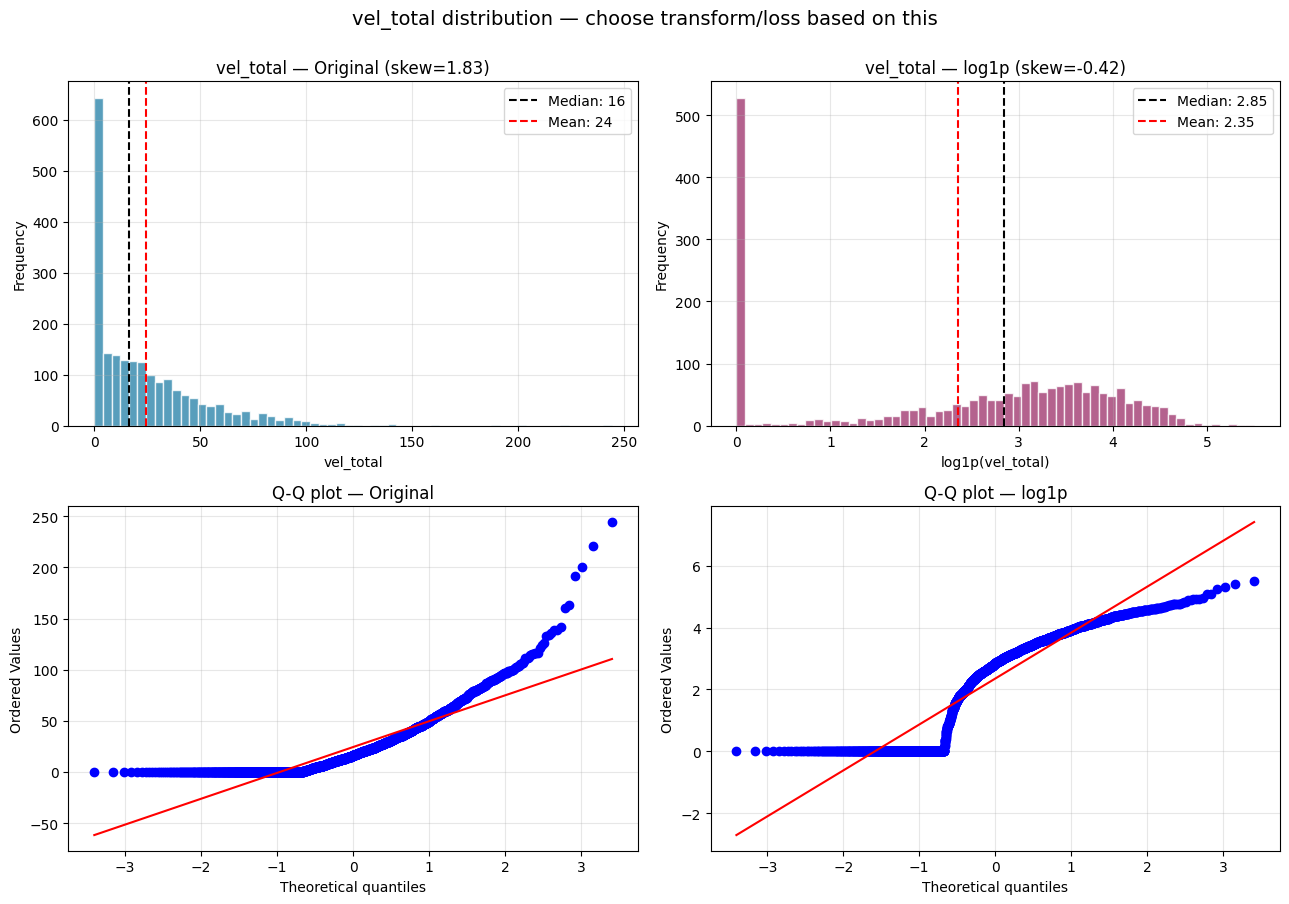

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Original distribution
axes[0, 0].hist(y, bins=60, color="#2E86AB", alpha=0.8, edgecolor="white")
axes[0, 0].axvline(y.median(), color="black", linestyle="--", label=f"Median: {y.median():.0f}")
axes[0, 0].axvline(y.mean(), color="red", linestyle="--", label=f"Mean: {y.mean():.0f}")
axes[0, 0].set_title(f"vel_total — Original (skew={y.skew():.2f})", fontsize=12)
axes[0, 0].set_xlabel("vel_total")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Log-transformed distribution
y_log = np.log1p(y)
axes[0, 1].hist(y_log, bins=60, color="#A23B72", alpha=0.8, edgecolor="white")
axes[0, 1].axvline(y_log.median(), color="black", linestyle="--", label=f"Median: {y_log.median():.2f}")
axes[0, 1].axvline(y_log.mean(), color="red", linestyle="--", label=f"Mean: {y_log.mean():.2f}")
axes[0, 1].set_title(f"vel_total — log1p (skew={y_log.skew():.2f})", fontsize=12)
axes[0, 1].set_xlabel("log1p(vel_total)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Q-Q plots
stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q plot — Original", fontsize=12)
axes[1, 0].grid(alpha=0.3)

stats.probplot(y_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot — log1p", fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.suptitle("vel_total distribution — choose transform/loss based on this", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / "vel_total_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()

### A.4 Modeling Decision Flags

In [5]:
print("\n" + "=" * 60)
print("Decision flags for modeling")
print("=" * 60)

zero_pct = (y == 0).mean() * 100
near_zero_pct = (y < 1).mean() * 100

if zero_pct > 20:
    print(f"⚠ Heavy zero-inflation: {zero_pct:.1f}% zeros")
    print("  → Strongly consider hurdle / two-stage model: classify zero/non-zero,")
    print("    then regress magnitude given non-zero.")
elif zero_pct > 5:
    print(f"⚠ Moderate zero-inflation: {zero_pct:.1f}% zeros")
    print("  → Tweedie loss appropriate; hurdle model could be considered")
else:
    print(f"✓ Low zero-inflation: {zero_pct:.1f}% zeros")

if near_zero_pct > 30:
    print(f"⚠ Many near-zero rows: {near_zero_pct:.1f}% are < 1")
    print("  → Predictions will cluster at low end; R² will suffer")

if y.skew() > 2:
    print(f"⚠ Heavy right skew (skew={y.skew():.2f})")
    print(f"  → Log transform recommended: yields skew={np.log1p(y).skew():.2f}")
elif y.skew() > 1:
    print(f"~ Moderate-heavy right skew (skew={y.skew():.2f})")
    print(f"  → Log or Tweedie both reasonable")
else:
    print(f"✓ Approximately symmetric (skew={y.skew():.2f}) — no transform needed")

if y.min() == 0:
    print("⚠ Target contains zeros — Gamma loss UNAVAILABLE")
elif y.min() > 0:
    print(f"✓ Target strictly positive (min={y.min():.2f}) — Gamma loss available")

print(f"\n  Note: vel_total represents high-speed running distance (band 6+7).")
print(f"  Many sessions/players legitimately produce zero HSR (recovery days,")
print(f"  central-back-style positions). Distribution is structurally bounded at 0.")


Decision flags for modeling
⚠ Heavy zero-inflation: 25.0% zeros
  → Strongly consider hurdle / two-stage model: classify zero/non-zero,
    then regress magnitude given non-zero.
~ Moderate-heavy right skew (skew=1.83)
  → Log or Tweedie both reasonable
⚠ Target contains zeros — Gamma loss UNAVAILABLE

  Note: vel_total represents high-speed running distance (band 6+7).
  Many sessions/players legitimately produce zero HSR (recovery days,
  central-back-style positions). Distribution is structurally bounded at 0.


---

## Part B — Model Training

Full XGBoost training pipeline with two-round SHAP-based feature selection.

### B.0 Setup

Imports, TARGET, and SHAP threshold constants.

In [6]:
"""
vel_total: Raw MSE + SHAP feature selection + extensive hyperparameter search.
- 17 base features + 35 player_id one-hots = 52 features (full)
- Step 1: Train full model with extensive RandomizedSearchCV + elastic net
- Step 2: SHAP-based feature selection (90% cumulative threshold)
- Step 3: Re-tune on reduced feature set
- Step 4: Pick winner by test MAE, save as final
- Learning curve diagnostic on the winner
"""

import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
# ---------------------------------------------------------------------------
# Repo-root resolver — works locally (notebooks/) and in Databricks (repo root)
# ---------------------------------------------------------------------------
import subprocess as _sp
from pathlib import Path as _Path

def _repo_root():
    try:
        return _Path(_sp.run(
            ["git", "rev-parse", "--show-toplevel"],
            capture_output=True, text=True, check=True,
        ).stdout.strip())
    except Exception:
        p = _Path.cwd()
        while p != p.parent:
            if (p / ".git").exists() or (p / "CLAUDE.md").exists():
                return p
            p = p.parent
        return _Path.cwd()

REPO_ROOT  = _repo_root()
DATA_DIR   = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
# ---------------------------------------------------------------------------

warnings.filterwarnings("ignore")

TARGET = "vel_total"
SHAP_KEEP_THRESHOLD = 0.90

### B.1 Load Preprocessed Data

Reads the feature-engineered dataset from `model_data.parquet`. Player identity one-hots are added here; the other two targets are dropped.

In [7]:
model_data = pd.read_parquet(DATA_DIR / "processed" / "model_data.parquet")
print(f"Loaded model_data: {model_data.shape}  |  {model_data.columns.tolist()}")

# Player identity one-hot encoding
player_dummies = pd.get_dummies(model_data["player_id"], prefix="pid", dtype=int)
model_data = pd.concat([model_data, player_dummies], axis=1)
print(f"Added {player_dummies.shape[1]} player_id one-hot columns")

# Keep only this target; drop the other two
DROP_COLS = ["player_id", "total_distance", "acc_total"]
model_data = model_data.drop(columns=[c for c in DROP_COLS if c in model_data.columns])
all_features = [c for c in model_data.columns if c != TARGET]

assert model_data.isna().sum().sum() == 0, "Unexpected NaNs in model_data"
print(f"Ready: {model_data.shape}  |  {len(all_features)} features")


Loaded model_data: (2103, 21)  |  ['player_id', 'total_distance', 'acc_total', 'vel_total', 'height', 'weight', 'age', 'has_G', 'has_TAC', 'has_BP', 'has_TEC', 'has_MATCH', 'n_session_types', 'pos_central_back', 'pos_central_midfielder', 'pos_forward', 'pos_full_back', 'pos_winger', 'days_since_start', 'days_since_last_activity', 'days_since_last_match']
Added 28 player_id one-hot columns
Ready: (2103, 46)  |  45 features


### B.2 Train / Test Split (Raw MSE)

In [8]:
X = model_data[all_features]
y = model_data[TARGET]
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)
print(f"\nTrain: {len(X_train_full)}  Test: {len(X_test_full)}")


Train: 1682  Test: 421


### B.3 Pipelines & Helpers

In [9]:
PARAM_DIST = {
    "xgb__n_estimators":     [200, 400, 600, 800, 1000, 1200, 1600, 2000],
    "xgb__learning_rate":    [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    "xgb__max_depth":        [3, 4, 5, 6, 7, 8],
    "xgb__min_child_weight": [1, 2, 3, 5, 7, 10],
    "xgb__subsample":        [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bylevel":[0.6, 0.8, 1.0],
    "xgb__gamma":            [0, 0.1, 0.3, 0.5, 1, 3, 5, 10],
    # Elastic net = L1 + L2 used together
    "xgb__reg_alpha":        [0, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50],
    "xgb__reg_lambda":       [0.1, 0.5, 1, 3, 5, 10, 25, 50, 100],
}
N_ITER = 100
CV = KFold(n_splits=5, shuffle=True, random_state=42)


def build_search_pipeline():
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("xgb", XGBRegressor(
            objective="reg:squarederror",  # Raw MSE
            tree_method="hist",
            random_state=42, n_jobs=-1, verbosity=0,
            early_stopping_rounds=50,
        )),
    ])


def build_lc_pipeline(params):
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("xgb", XGBRegressor(
            **params,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=42, n_jobs=-1, verbosity=0,
        )),
    ])


def evaluate(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
    }


def tune_and_eval(X_train, X_test, y_train, y_test, label):
    print(f"\n--- {label} ({X_train.shape[1]} features) ---")
    n_train = len(X_train)
    val_size = max(int(n_train * 0.15), 50)
    rng = np.random.default_rng(42)
    val_idx = rng.choice(n_train, size=val_size, replace=False)
    train_idx_es = np.setdiff1d(np.arange(n_train), val_idx)

    es_scaler = MinMaxScaler().fit(X_train.iloc[train_idx_es])
    X_es_val = es_scaler.transform(X_train.iloc[val_idx])
    y_es_val = y_train.iloc[val_idx].values

    fit_params = {"xgb__eval_set": [(X_es_val, y_es_val)], "xgb__verbose": False}

    search = RandomizedSearchCV(
        estimator=build_search_pipeline(),
        param_distributions=PARAM_DIST,
        n_iter=N_ITER, cv=CV,
        scoring="neg_mean_absolute_error",
        n_jobs=-1, random_state=42, verbose=1, return_train_score=False,
    )
    search.fit(X_train, y_train, **fit_params)
    best = search.best_estimator_

    y_train_pred = np.clip(best.predict(X_train), 0, None)
    y_test_pred = np.clip(best.predict(X_test), 0, None)
    train_m = evaluate(y_train, y_train_pred)
    test_m  = evaluate(y_test, y_test_pred)

    print(f"  Best CV MAE: {-search.best_score_:.4f}")
    print(f"  Best params: " + ", ".join(f"{k.replace('xgb__','')}={v}" for k, v in search.best_params_.items()))
    print(f"  Train: MAE={train_m['MAE']:.4f}  R²={train_m['R2']:.4f}")
    print(f"  Test:  MAE={test_m['MAE']:.4f}   R²={test_m['R2']:.4f}")
    return best, train_m, test_m, search.best_params_

### B.4 Round 1 — Full Features

In [10]:
print("\n" + "=" * 70)
print(f"ROUND 1: All {len(all_features)} features, Raw MSE")
print("=" * 70)
best_full, train_full, test_full, params_full = tune_and_eval(
    X_train_full, X_test_full, y_train, y_test, "FULL FEATURES"
)


ROUND 1: All 45 features, Raw MSE

--- FULL FEATURES (45 features) ---
Fitting 5 folds for each of 100 candidates, totalling 500 fits
  Best CV MAE: 18.7333
  Best params: subsample=1.0, reg_lambda=5, reg_alpha=10, n_estimators=200, min_child_weight=2, max_depth=3, learning_rate=0.07, gamma=0.3, colsample_bytree=1.0, colsample_bylevel=0.8
  Train: MAE=16.6191  R²=0.3446
  Test:  MAE=18.3157   R²=0.1593


### B.5 SHAP Feature Selection (90% Threshold)

In [ ]:
print("\n--- SHAP analysis ---")
scaler = best_full.named_steps["scaler"]
xgb_model = best_full.named_steps["xgb"]
X_test_scaled = pd.DataFrame(scaler.transform(X_test_full), columns=all_features, index=X_test_full.index)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=all_features).sort_values(ascending=False)

# 90% cumulative threshold
total_importance = shap_importance.sum()
cumulative = shap_importance.cumsum() / total_importance
features_kept = cumulative[cumulative <= SHAP_KEEP_THRESHOLD].index.tolist()
if len(features_kept) == 0:
    features_kept = [shap_importance.index[0]]
if len(features_kept) < len(shap_importance):
    features_kept.append(shap_importance.index[len(features_kept)])

print(f"\nSHAP cumulative threshold: {SHAP_KEEP_THRESHOLD * 100:.0f}%")
print(f"Features kept: {len(features_kept)} / {len(all_features)}")

print("\nFeatures kept (SHAP importance):")
for feat in features_kept:
    is_pid = " [pid]" if feat.startswith("pid_") else ""
    print(f"  {feat:30s} {shap_importance[feat]:>10.4f}{is_pid}")

# Cumulative plot
plt.figure(figsize=(11, 5))
sorted_importance = shap_importance.values
cumulative_pct = sorted_importance.cumsum() / sorted_importance.sum() * 100
plt.plot(range(1, len(sorted_importance) + 1), cumulative_pct, "o-", color="#2E86AB", markersize=4)
plt.axhline(SHAP_KEEP_THRESHOLD * 100, color="red", linestyle="--", linewidth=1.5, label=f"{SHAP_KEEP_THRESHOLD * 100:.0f}% threshold")
plt.axvline(len(features_kept), color="gray", linestyle=":", linewidth=1.5, label=f"{len(features_kept)} features kept")
plt.xlabel("Number of features (sorted by SHAP importance, desc)")
plt.ylabel("Cumulative importance (%)")
plt.title(f"SHAP cumulative importance — {TARGET} (Raw MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
MODELS_DIR.mkdir(exist_ok=True)
plt.savefig(str(MODELS_DIR / f"{TARGET}_shap_cumulative.png"), dpi=120, bbox_inches="tight")
plt.show()

### B.6 Round 2 — SHAP-Reduced Features

In [ ]:
X_train_reduced = X_train_full[features_kept]
X_test_reduced = X_test_full[features_kept]

print("\n" + "=" * 70)
print(f"ROUND 2: SHAP-reduced ({len(features_kept)} features)")
print("=" * 70)
best_reduced, train_reduced, test_reduced, params_reduced = tune_and_eval(
    X_train_reduced, X_test_reduced, y_train, y_test, "REDUCED"
)

### B.7 Model Comparison & Winner Selection

In [ ]:
print("\n" + "=" * 70)
print("FINAL COMPARISON (Raw MSE)")
print("=" * 70)
print(f"{'CONFIG':<30}  {'TRAIN MAE':>10}  {'TRAIN R²':>10}  {'TEST MAE':>10}  {'TEST R²':>10}")
print("-" * 80)
print(f"{'Full (' + str(len(all_features)) + ' feat)':<30}  {train_full['MAE']:>10.4f}  {train_full['R2']:>10.4f}  {test_full['MAE']:>10.4f}  {test_full['R2']:>10.4f}")
print(f"{'SHAP-reduced (' + str(len(features_kept)) + ' feat)':<30}  {train_reduced['MAE']:>10.4f}  {train_reduced['R2']:>10.4f}  {test_reduced['MAE']:>10.4f}  {test_reduced['R2']:>10.4f}")

# Pick winner by test MAE
if test_reduced["MAE"] < test_full["MAE"]:
    winner = "REDUCED"
    winner_model = best_reduced
    winner_features = features_kept
    winner_params = params_reduced
    winner_test = test_reduced
else:
    winner = "FULL"
    winner_model = best_full
    winner_features = all_features
    winner_params = params_full
    winner_test = test_full

print(f"\n→ Winner: {winner}")

### B.8 Learning Curve — Bias-Variance Diagnostic

In [ ]:
print("\n--- Generating learning curve for winner ---")
X_train_winner = X_train_full[winner_features]

best_params_only = {k.replace("xgb__", ""): v for k, v in winner_params.items()}
lc_pipeline = build_lc_pipeline(best_params_only)

train_sizes_pct = np.linspace(0.1, 1.0, 10)
train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_pipeline, X_train_winner, y_train,
    train_sizes=train_sizes_pct, cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1, shuffle=True, random_state=42,
)

train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)
train_mae_std = train_scores.std(axis=1)
val_mae_std   = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mae, "o-", color="#2E86AB", label="Training MAE", linewidth=2)
plt.plot(train_sizes_abs, val_mae,   "o-", color="#E63946", label="Validation MAE", linewidth=2)
plt.fill_between(train_sizes_abs, train_mae - train_mae_std, train_mae + train_mae_std, alpha=0.15, color="#2E86AB")
plt.fill_between(train_sizes_abs, val_mae - val_mae_std, val_mae + val_mae_std, alpha=0.15, color="#E63946")
plt.xlabel("Training set size", fontsize=12)
plt.ylabel("MAE (m)", fontsize=12)
plt.title(f"Learning Curve: {TARGET} (Raw MSE, {winner})", fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(MODELS_DIR / f"{TARGET}_learning_curve.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"  Train MAE: {train_mae[-1]:.4f}")
print(f"  Val MAE:   {val_mae[-1]:.4f}")
print(f"  Gap:       {val_mae[-1] - train_mae[-1]:.4f}")

### B.9 Model Persistence

In [ ]:
OUT = MODELS_DIR
OUT.mkdir(exist_ok=True)
with open(OUT / f"{TARGET}_model.pkl", "wb") as f:
    pickle.dump(winner_model, f)
with open(OUT / f"{TARGET}_feature_cols.pkl", "wb") as f:
    pickle.dump(winner_features, f)
with open(OUT / f"{TARGET}_transform.pkl", "wb") as f:
    pickle.dump({"type": "none", "loss": "mse"}, f)
print(f"\nSaved: {OUT / f'{TARGET}_model.pkl'} ({winner}, {len(winner_features)} features, Raw MSE)")
print(f"Saved: {OUT / f'{TARGET}_transform.pkl'} (no inverse transform — predictions in original units, clip negative at 0)")

### B.10 Final Metrics

In [ ]:
print("\n" + "=" * 70)
print(f"FINAL: {TARGET} (Raw MSE, {winner})")
print("=" * 70)
print(f"  Test MAE:  {winner_test['MAE']:.4f}")
print(f"  Test RMSE: {winner_test['RMSE']:.4f}")
print(f"  Test R²:   {winner_test['R2']:.4f}")

In [ ]:
# ─── SYNC: regenerate utils/train_vel_total.py from this notebook ────────────
import json, re
from pathlib import Path

_NB  = Path("vel_total.ipynb")
_OUT = Path("../utils/train_vel_total.py")
_MAGIC = re.compile(r"^\s*[%!]")
_HEADER = (
    "# AUTO-GENERATED from notebooks/vel_total.ipynb\n"
    "# Re-run the last notebook cell to update.\n\n"
)

with _NB.open() as _f:
    _nb = json.load(_f)

_lines = [_HEADER]
for _cell in _nb["cells"]:
    if _cell["cell_type"] != "code":
        continue
    _src = "".join(_cell["source"])
    if "SYNC: regenerate" in _src:
        continue
    _filtered = "\n".join(
        ln for ln in _src.splitlines() if not _MAGIC.match(ln)
    ).strip()
    if _filtered:
        _lines.append(_filtered + "\n\n\n")

_OUT.parent.mkdir(exist_ok=True)
_OUT.write_text("".join(_lines))
print(f"Synced → {_OUT.resolve()}")